In [53]:
# Data Handling
import pandas as pd
import numpy as np

# Text Processing
import re

# Visualization
import matplotlib.pyplot as plt

# Train/Test Split
from sklearn.model_selection import train_test_split

# TensorFlow / Keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Evaluation
from nltk.translate.bleu_score import corpus_bleu

# Reproducibility
import tensorflow as tf
np.random.seed(42)
tf.random.set_seed(42)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [54]:
# Read Arabic-English Dataset
data = []

with open("ara.txt", encoding="utf-8") as f:
    for line in f:
        parts = line.strip().split('\t')

        if len(parts) >= 2:
            english = parts[0]
            arabic = parts[1]

            data.append([arabic, english])

df = pd.DataFrame(data, columns=["arabic", "english"])




In [55]:
print(df.head())

           arabic english
0         مرحبًا.     Hi.
1           اركض!    Run!
2      اخفض رأسك!   Duck!
3     اخفضي رأسك!   Duck!
4  اخفضوا رؤوسكم!   Duck!


In [56]:
print(df.shape)

(12523, 2)


In [57]:
df = df.sample(10000, random_state=42)

df.reset_index(drop=True, inplace=True)

In [58]:
# Arabic Cleaning
import re

def clean_arabic(text):

    text = str(text)

    text = re.sub(r'[ًٌٍَُِّْـ]', '', text)

    text = re.sub(r'[^\u0600-\u06FF\s]', '', text)

    text = re.sub(r'\s+', ' ', text)

    return text.strip()

In [59]:
# English Cleaning
def clean_english(text):

    text = text.lower()

    text = re.sub(r"[^a-zA-Z ]", "", text)

    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [60]:
# Apply Cleaning
df["arabic"] = df["arabic"].apply(clean_arabic)

df["english"] = df["english"].apply(clean_english)

In [61]:
# Add Start and End Tokens
df["english"] = (
    "<start> "
    + df["english"]
    + " <end>"
)

In [62]:
# Train/Test Split
train_df, test_df = train_test_split(
    df,
    test_size=0.1,
    random_state=42
)

In [63]:
# Tokenization
arabic_tokenizer = Tokenizer(
    filters=''
)

arabic_tokenizer.fit_on_texts(
    train_df["arabic"]
)

In [64]:
english_tokenizer = Tokenizer(
    filters=''
)

english_tokenizer.fit_on_texts(
    train_df["english"]
)

In [65]:
# Convert to Sequences
encoder_sequences = arabic_tokenizer.texts_to_sequences(
    train_df["arabic"]
)

decoder_sequences = english_tokenizer.texts_to_sequences(
    train_df["english"]
)

In [66]:
# Padding
max_encoder_len = max(
    len(seq)
    for seq in encoder_sequences
)

max_decoder_len = max(
    len(seq)
    for seq in decoder_sequences
)

In [67]:
encoder_input = pad_sequences(
    encoder_sequences,
    maxlen=max_encoder_len,
    padding="post"
)

decoder_input = pad_sequences(
    decoder_sequences,
    maxlen=max_decoder_len,
    padding="post"
)

In [68]:
# Create Decoder Targets
decoder_target = np.zeros_like(
    decoder_input
)

decoder_target[:, :-1] = (
    decoder_input[:, 1:]
)

In [69]:
# Encoder
encoder_inputs = Input(
    shape=(max_encoder_len,)
)

encoder_embedding = Embedding(
    input_dim=len(arabic_tokenizer.word_index)+1,
    output_dim=256,
    mask_zero=True
)(encoder_inputs)

encoder_outputs, state_h, state_c = LSTM(
    256,
    return_state=True
)(encoder_embedding)

encoder_states = [state_h, state_c]

In [98]:
# Decoder
decoder_inputs = Input(
    shape=(max_decoder_len,)
)

decoder_embedding_layer = Embedding( # Renamed to _layer
    input_dim=len(english_tokenizer.word_index)+1,
    output_dim=256,
    mask_zero=True
)
decoder_embedding_output = decoder_embedding_layer(decoder_inputs) # Used for training

decoder_lstm_layer = LSTM( # Renamed to _layer
    256,
    return_sequences=True,
    return_state=True
)

decoder_outputs, _, _ = decoder_lstm_layer( # Used the layer object
    decoder_embedding_output,
    initial_state=encoder_states
)

decoder_dense_layer = Dense( # Renamed to _layer
    len(english_tokenizer.word_index)+1,
    activation='softmax'
)

decoder_outputs = decoder_dense_layer( # Used the layer object
    decoder_outputs
)

In [71]:
# Compile
model = Model(
    [encoder_inputs, decoder_inputs],
    decoder_outputs
)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [72]:
# Callbacks
callbacks = [

    EarlyStopping(
        patience=5,
        restore_best_weights=True
    ),

    ModelCheckpoint(
        "best_translation.keras",
        save_best_only=True
    )
]

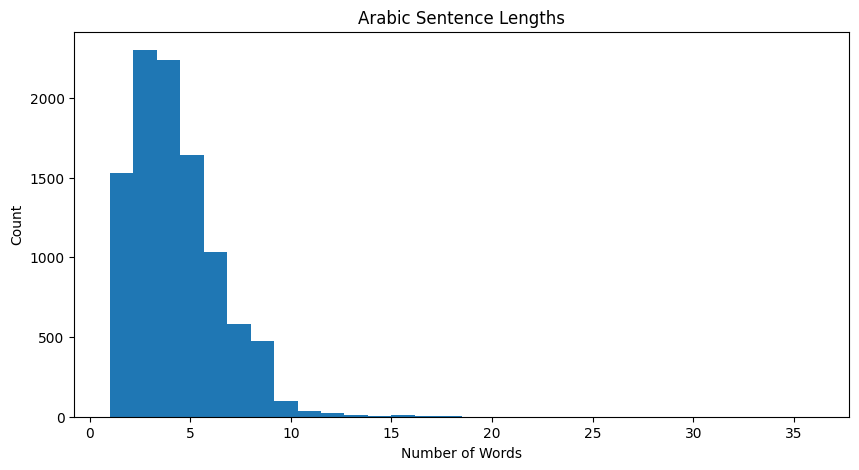

In [73]:
arabic_lengths = df["arabic"].apply(
    lambda x: len(x.split())
)

plt.figure(figsize=(10,5))

plt.hist(arabic_lengths,
         bins=30)

plt.title("Arabic Sentence Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Count")

plt.show()

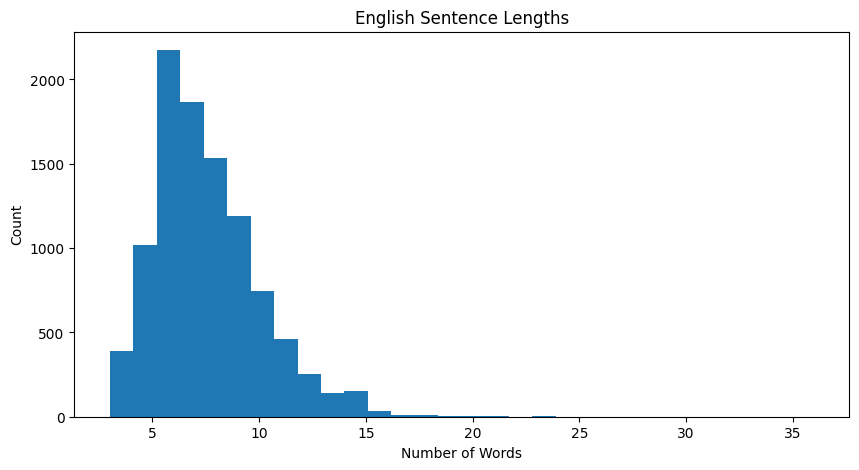

In [74]:
english_lengths = df["english"].apply(
    lambda x: len(x.split())
)

plt.figure(figsize=(10,5))

plt.hist(english_lengths,
         bins=30)

plt.title("English Sentence Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Count")

plt.show()

In [75]:
arabic_vocab_size = len(
    arabic_tokenizer.word_index
)

english_vocab_size = len(
    english_tokenizer.word_index
)

In [76]:
# Train
history = model.fit(
    [encoder_input, decoder_input],
    np.expand_dims(
        decoder_target,
        -1
    ),
    validation_split=0.1,
    batch_size=64,
    epochs=50,
    callbacks=callbacks
)

Epoch 1/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 130s 995ms/step - accuracy: 0.2509 - loss: 5.3162 - val_accuracy: 0.2914 - val_loss: 4.6787
Epoch 2/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 127s 1000ms/step - accuracy: 0.3122 - loss: 4.4001 - val_accuracy: 0.3149 - val_loss: 4.4850
Epoch 3/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 138s 968ms/step - accuracy: 0.3292 - loss: 4.1529 - val_accuracy: 0.3291 - val_loss: 4.3390
Epoch 4/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 143s 975ms/step - accuracy: 0.3478 - loss: 3.9228 - val_accuracy: 0.3452 - val_loss: 4.1744
Epoch 5/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 159s 1s/step - accuracy: 0.3692 - loss: 3.6781 - val_accuracy: 0.3590 - val_loss: 4.0194
Epoch 6/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 126s 990ms/step - accuracy: 0.3923 - loss: 3.4454 - val_accuracy: 0.3794 - val_loss: 3.8998
Epoch 7/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 147s 1s/step - accuracy: 0.4196 - loss: 3.2430 - val_accuracy: 0.3954 - val_loss: 3.7893
Epoch 8/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 129s 1s/step - accuracy: 0.4422 - loss: 3

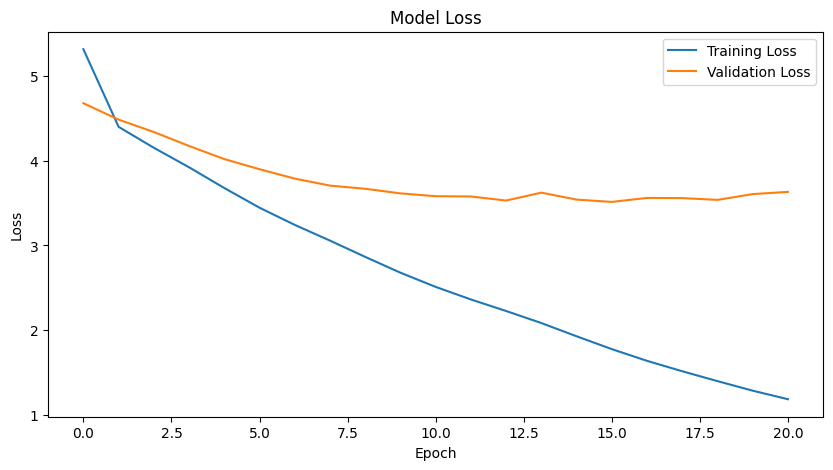

In [77]:
# Model Loss
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'],
         label='Training Loss')

plt.plot(history.history['val_loss'],
         label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

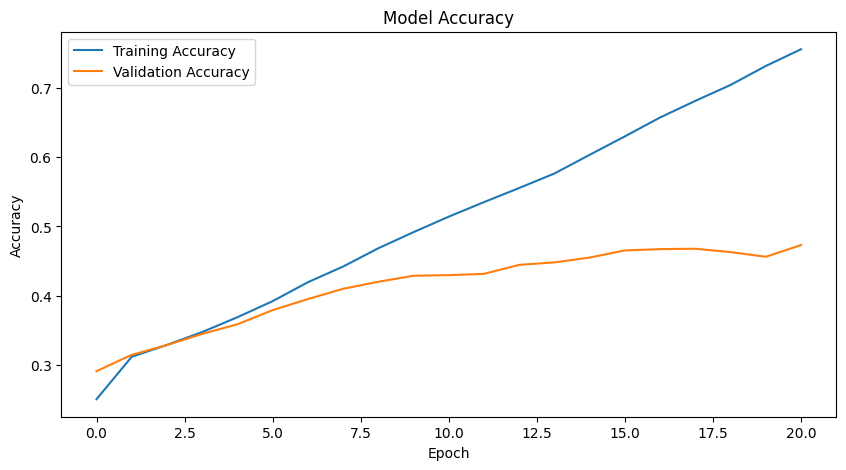

In [78]:
# Model Accuracy
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'],
         label='Training Accuracy')

plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()

plt.show()

In [82]:
# Translate a Sentence
sentence = "أنا طالب"

In [83]:
sequence = arabic_tokenizer.texts_to_sequences(
    [sentence]
)

sequence = pad_sequences(
    sequence,
    maxlen=max_encoder_len,
    padding='post'
)

In [85]:
encoder_model = Model(encoder_inputs, encoder_states)

# Get Encoder States
states_value = encoder_model.predict(
    sequence,
    verbose=0
)

In [86]:
# Start Decoder
target_seq = np.zeros((1,1))

target_seq[0,0] = (
    english_tokenizer.word_index['start']
)

In [99]:
decoder_state_input_h = Input(shape=(256,))
decoder_state_input_c = Input(shape=(256,))
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

# Define new input for single word prediction (shape=(1,) for one word at a time)
decoder_inputs_inference = Input(shape=(1,))

# Apply the embedding layer to the single-word input
decoder_embedding_inference_output = decoder_embedding_layer(decoder_inputs_inference)

# Apply the LSTM layer for inference
decoder_outputs2, state_h2, state_c2 = decoder_lstm_layer(
    decoder_embedding_inference_output,
    initial_state=decoder_states_inputs
)
decoder_states2 = [state_h2, state_c2]

# Apply the dense layer for output
decoder_outputs2 = decoder_dense_layer(
    decoder_outputs2
)

decoder_model = Model(
    [decoder_inputs_inference] + decoder_states_inputs,
    [decoder_outputs2] + decoder_states2
)

reverse_eng_index = {v: k for k, v in english_tokenizer.word_index.items()}

In [95]:
def decode_sequence(input_seq, encoder_model, decoder_model, reverse_eng_index, max_len=30):
    # Encode input once and convert states to tensors immediately
    states_value_np = encoder_model.predict(input_seq, verbose=0)
    states_value = [tf.convert_to_tensor(s) for s in states_value_np]

    # Initialize target_seq as a NumPy array and convert to a TensorFlow tensor
    target_seq_np = np.zeros((1, 1))
    target_seq_np[0, 0] = reverse_eng_index.get('start', 0)
    target_seq = tf.convert_to_tensor(target_seq_np, dtype=tf.int32)

    decoded_sentence = []

    for _ in range(max_len):
        # Pass tensors directly to the decoder model
        output_tokens, h, c = decoder_model([target_seq] + states_value)

        # Get most likely token, convert from tensor to numpy for dictionary lookup
        sampled_token_index = tf.argmax(output_tokens[0, -1, :]).numpy()

        # Convert token to word
        sampled_word = reverse_eng_index.get(sampled_token_index, '')

        # Stop condition
        if sampled_word == '' or sampled_word == 'end':
            break

        decoded_sentence.append(sampled_word)

        # Update input for next step, ensure it remains a tensor
        target_seq = tf.constant(sampled_token_index, shape=(1, 1), dtype=tf.int32)

        # Update states (h and c are already tensors from decoder_model output)
        states_value = [h, c]

    return ' '.join(decoded_sentence)

In [107]:
from nltk.translate.bleu_score import SmoothingFunction

def translate(input_sentence):
    sequence = arabic_tokenizer.texts_to_sequences([input_sentence])
    sequence = pad_sequences(
        sequence,
        maxlen=max_encoder_len,
        padding='post'
    )
    return decode_sequence(sequence, encoder_model, decoder_model, reverse_eng_index, max_decoder_len)

# Evaluate Multiple Predictions
references = []
predictions = []

for i in range(10):

    arabic_text = test_df.iloc[i]["arabic"]

    true_translation = test_df.iloc[i]["english"]

    predicted_translation = translate(
        arabic_text
    )

    cleaned_true_translation = true_translation.replace("<start>", "").replace("<end>", "").strip().split()
    references.append([cleaned_true_translation])
    predictions.append(predicted_translation.split())


    print("Arabic:")
    print(arabic_text)

    print("Actual:")
    print(true_translation)

    print("Predicted:")
    print(predicted_translation)

    print("-"*50)

# Calculate BLEU score after populating lists
smooth_func = SmoothingFunction().method1

score = corpus_bleu(
    references,
    predictions,
    smoothing_function=smooth_func
)

print(
    f"BLEU Score: {score:.4f}"
)

Arabic:
اسكت
Actual:
<start> shut up <end>
Predicted:
kidding taxi taxi intent intent intent monotheistic monotheistic monotheistic monotheistic monotheistic terrible monotheistic love fuji fuji fuji fuji raised rewrote creature smiles punishing sweden abusing circumstances lobby vase sacred called fall upset should should italy frisbee
--------------------------------------------------
Arabic:
أطلق على توم فقتل
Actual:
<start> tom was shot and killed <end>
Predicted:
nowhere discussed final final final final final final final final final final final land land land land disappeared pepper disappeared luckily talking listener pepper agree agree agree confident crimes tolerant like remote crimes butterfly bracelet west
--------------------------------------------------
Arabic:
نحن ننتظرك منذ مدة أين كنت؟
Actual:
<start> weve been waiting for you for ages where were you <end>
Predicted:
december december december laundry laundry laundry final final final final final final final final seco